# Crypto Polymarket -- Analysis

Looks at the markets `src/filtering/keyword_filter.py` flagged as crypto. Single input:
`data/processed/filtered_crypto_markets.jsonl` -- every kept record already carries the
coin it matched (`matched_coin`), so there's no separate match-log file to join against
here (the old version of this notebook, from before that filter existed, needed one --
this is the version that doesn't).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 60)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

REPO_ROOT = Path.cwd().parent
JSONL_PATH = REPO_ROOT / "data" / "processed" / "filtered_crypto_markets.jsonl"


## 1. Loading the data

Streams the file line by line so memory stays flat regardless of file size, pulling out
just the fields these analyses need.

In [2]:
rows = []
with open(JSONL_PATH, encoding="utf-8") as f:
    for line in f:
        m = json.loads(line)
        ev = (m.get("events") or [{}])[0]
        se = (ev.get("series") or [{}])[0]
        rows.append({
            "id": str(m.get("id", "")),
            "coin": m.get("matched_coin"),
            "volume": pd.to_numeric(m.get("volumeNum", m.get("volume")), errors="coerce"),
            "createdAt": m.get("createdAt"),
            "closed": bool(m.get("closed")),
            "active": bool(m.get("active")),
            "series_slug": se.get("slug", ""),
        })

df = pd.DataFrame(rows)
df["createdAt"] = pd.to_datetime(df["createdAt"], errors="coerce", utc=True, format="ISO8601")
print(f"{len(df):,} crypto markets loaded, {df['coin'].nunique()} distinct coins")
df.head()


634,680 crypto markets loaded, 43 distinct coins


,id,coin,volume,createdAt,closed,active,series_slug
0,2842657,ethereum,115.000,2026-07-08 05:40:12.038879+00:00,True,True,ethereum-multi-strikes-hourly
1,2842656,ethereum,115.000,2026-07-08 05:40:11.855619+00:00,True,True,ethereum-multi-strikes-hourly
2,2842655,ethereum,115.000,2026-07-08 05:40:11.626589+00:00,True,True,ethereum-multi-strikes-hourly
3,2842654,ethereum,115.000,2026-07-08 05:40:11.453154+00:00,True,True,ethereum-multi-strikes-hourly
4,2842653,ethereum,114.993,2026-07-08 05:40:11.248585+00:00,True,True,ethereum-multi-strikes-hourly


## 2. Markets per coin

One row per market already carries its matched coin -- no de-duplication or hit-counting
needed, just a group-by.

Top 20 coins by #markets:


,markets
coin,
bitcoin,146361
ethereum,138964
solana,100787
ripple,99766
hyperliquid,49492
dogecoin,49468
binancecoin,49371
ethena,112
chainlink,106


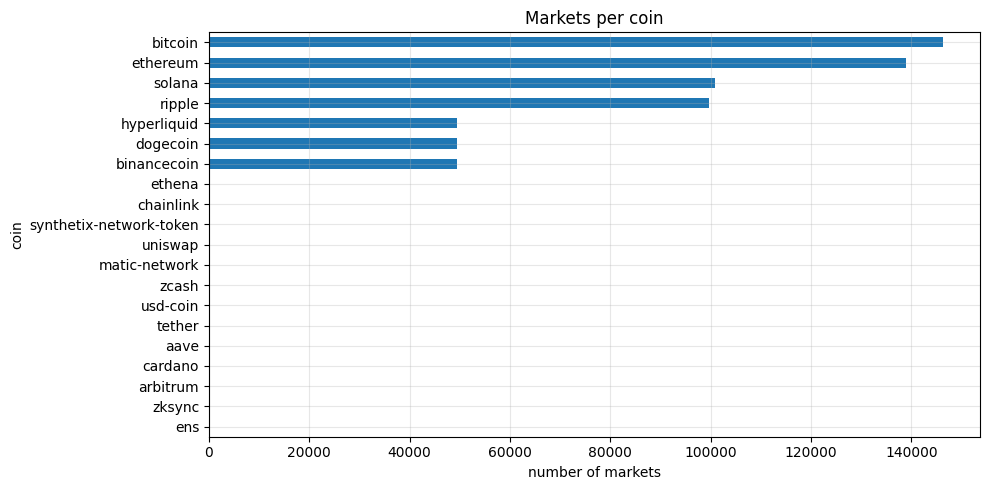

In [3]:
coin_counts = df.groupby("coin")["id"].nunique().sort_values(ascending=False)

print("Top 20 coins by #markets:")
display(coin_counts.head(20).to_frame("markets"))

top = coin_counts.head(20)
ax = top.iloc[::-1].plot.barh()
ax.set_xlabel("number of markets"); ax.set_title("Markets per coin")
plt.tight_layout(); plt.show()


## 3. How much comes from recurring series?

Polymarket auto-generates large batches of recurring price markets (e.g. *Ethereum Multi
Strikes Hourly*). A handful of series could account for most of the total, which matters
for how the dataset should be interpreted -- "many markets" isn't the same as "many
distinct questions."

133 distinct series. Top 15 by market count:


,markets
series_slug,
btc-up-or-down-5m,54124
sol-up-or-down-5m,52170
eth-up-or-down-5m,52163
xrp-up-or-down-5m,52160
bitcoin-multi-strikes-hourly,35999
bnb-up-or-down-5m,34098
hype-up-or-down-5m,34095
doge-up-or-down-5m,34094
ethereum-multi-strikes-hourly,32001



Top 20 series account for 88.1% of all crypto markets.


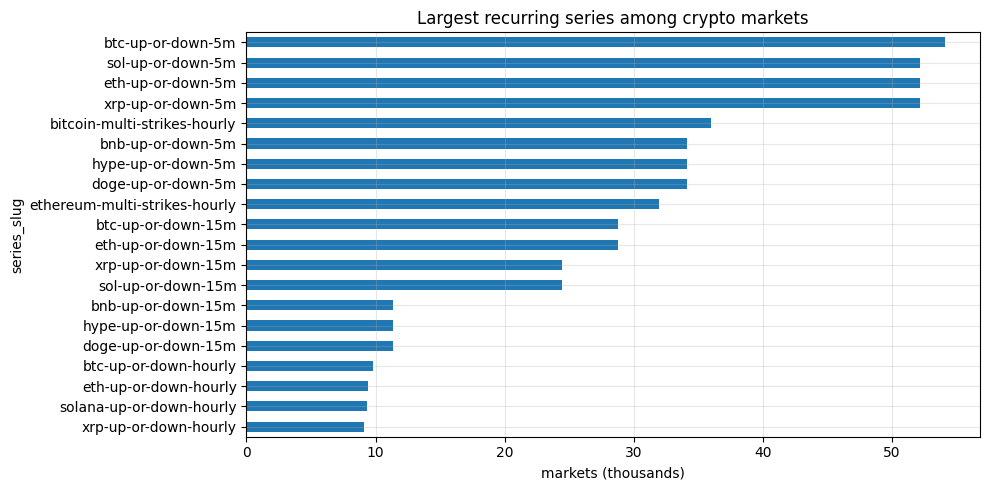

In [4]:
sc = df[df["series_slug"] != ""]["series_slug"].value_counts()
print(f"{len(sc):,} distinct series. Top 15 by market count:")
display(sc.head(15).to_frame("markets"))

topk = min(20, len(sc))
share = sc.cumsum() / len(df)
print(f"\nTop {topk} series account for {share.iloc[topk-1]*100:.1f}% of all crypto markets.")

ax = (sc.head(20) / 1000).iloc[::-1].plot.barh()
ax.set_xlabel("markets (thousands)"); ax.set_title("Largest recurring series among crypto markets")
plt.tight_layout(); plt.show()


## 4. Market creation over time

C:\Users\Erulan\AppData\Local\Temp\ipykernel_35332\2775053182.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df["createdAt"].dt.to_period("M")).size())


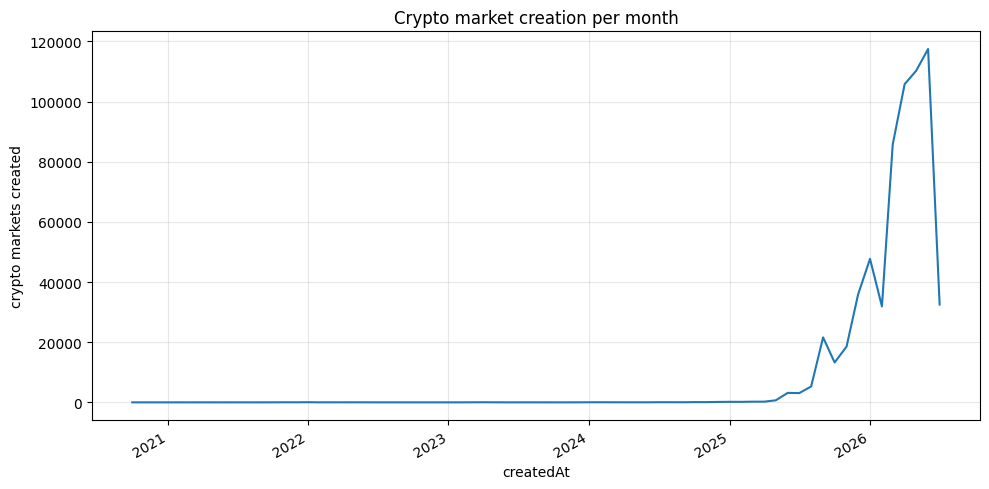

peak month: 2026-06-01 -> 117,453 markets


In [5]:
ts = (df.dropna(subset=["createdAt"])
        .groupby(df["createdAt"].dt.to_period("M")).size())
ts.index = ts.index.to_timestamp()

ax = ts.plot()
ax.set_ylabel("crypto markets created"); ax.set_title("Crypto market creation per month")
plt.tight_layout(); plt.show()
print("peak month:", ts.idxmax().date(), "->", f"{int(ts.max()):,} markets")


## 5. Volume

Most auto-generated price markets have very little volume -- this separates *many
markets* from *much traded*.

markets with volume == 0 : 23.2%
median volume            : 859
total volume             : 15,023,099,300


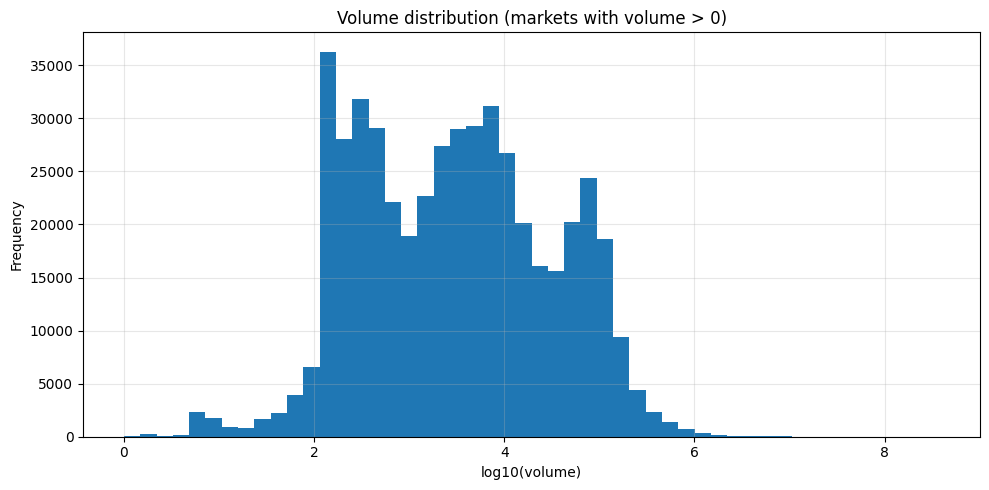


Total traded volume by coin (top 20):


,total_volume
coin,
bitcoin,1.083142e+10
ethereum,2.621674e+09
solana,8.637520e+08
ripple,5.302871e+08
dogecoin,7.075174e+07
hyperliquid,3.447481e+07
binancecoin,2.376878e+07
usd-coin,6.942683e+06
zcash,6.359695e+06


In [6]:
v = df["volume"].fillna(0)
print(f"markets with volume == 0 : {(v == 0).mean()*100:.1f}%")
print(f"median volume            : {v.median():,.0f}")
print(f"total volume             : {v.sum():,.0f}")

vv = v[v > 0]
ax = np.log10(vv).plot.hist(bins=50)
ax.set_xlabel("log10(volume)"); ax.set_title("Volume distribution (markets with volume > 0)")
plt.tight_layout(); plt.show()

vol_by_coin = df.groupby("coin")["volume"].sum().sort_values(ascending=False).head(20)
print("\nTotal traded volume by coin (top 20):")
display(vol_by_coin.to_frame("total_volume").round(0))


## 6. Open vs. closed

In [7]:
print(df["closed"].value_counts().rename({True: "closed", False: "open"}))

oc = df.groupby("coin")["closed"].agg(["size", "mean"]).sort_values("size", ascending=False).head(15)
oc.columns = ["markets", "closed_fraction"]
print("\nOpen/closed by coin (top 15 by market count):")
display(oc.round(2))


closed
closed    632382
open        2298
Name: count, dtype: int64



Open/closed by coin (top 15 by market count):


,markets,closed_fraction
coin,,
bitcoin,146361,1.00
ethereum,138964,1.00
solana,100787,1.00
ripple,99766,1.00
hyperliquid,49492,1.00
dogecoin,49468,1.00
binancecoin,49371,1.00
ethena,112,0.84
chainlink,106,0.85


## Notes

- **Recurring series.** Section 3 shows whether a few series account for most of the
  total -- if so, a market count on its own overstates how many distinct questions the
  dataset actually represents.
- **What's not here.** The earlier version of this notebook also measured which raw
  fields (slug/question/event/series) caught which markets, since it was auditing a
  filter that logged every field-level hit. `keyword_filter.py` doesn't produce that
  log -- it decides once per market and moves on -- so there's nothing left to audit
  that way; `docs/crypto_filter_design.md` has that reasoning if it's ever needed again.